<a href="https://colab.research.google.com/github/khanyisa-mabasa/KHANYISA-MABASA-PORTFOLIOO/blob/main/salary_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import statistics as stats


mydata=pd.read_csv('/content/Salary_Data_.csv')
mydata.describe()


,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [ ]:
mydata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


In [ ]:
mydata

In [ ]:
display(mydata.head())

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


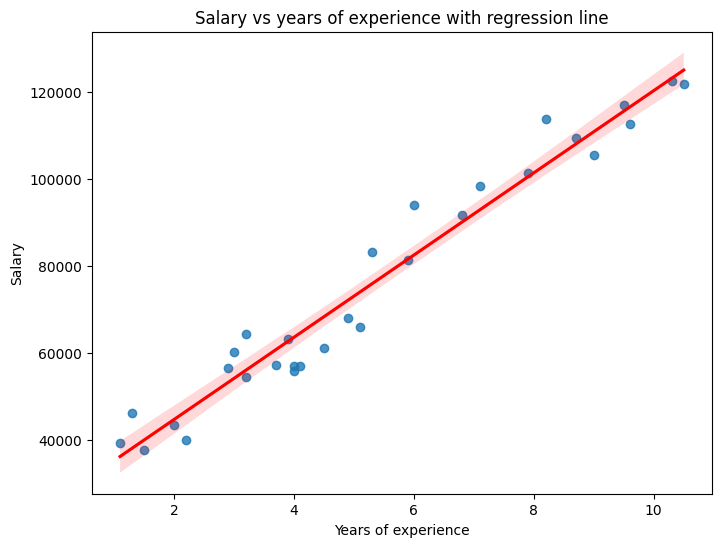

In [ ]:



#Scatter Plot

plt.figure(figsize=(5,3))
sns.regplot(x='YearsExperience',y='Salary',data=mydata, line_kws={"color": "red"})
plt.xlabel('Years of experience')
plt.ylabel('Salary')
plt.title('Salary vs years of experience with regression line')
#plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



In [ ]:
from sklearn.model_selection import train_test_split

X=mydata[['YearsExperience']]
Y=mydata['Salary']

X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=1)

print("Training set shape (X_train, y_train:)", X_train.shape, y_train.shape)
print("Testing set shape (X_test, y_test:)", X_test.shape, y_test.shape)

Training set shape (X_train, y_train:) (24, 1) (24,)
Testing set shape (X_test, y_test:) (6, 1) (6,)


In [ ]:
from sklearn.linear_model import LinearRegression

#Create a linear regresssion model
model = LinearRegression()

#Training the model using the training data
model.fit(X_train, y_train)

print("Linear Regression model created and trained")
print("Intercept (b):)", model.intercept_)
print("Coefficient (a):)", model.coef_[0])

Linear Regression model created and trained
Intercept (b):) 25609.89799835482
Coefficient (a):) 9332.94473799272


In [ ]:
#Make predictions on the testing data
y_pred=model.predict(X_test)

#Display the actual and predicted salaries
results_df = pd.DataFrame({'Actual Salary': y_test, 'Predicted salary': y_pred})
display(results_df)

,Actual Salary,Predicted salary
17,83088,75074.505110
21,98273,91873.805638
10,63218,62008.382477
19,93940,81607.566426
14,61111,67608.149319
20,91738,89073.922217


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

#Calculate  evaluate metrics using results_df
mae =  mean_absolute_error(results_df['Actual Salary'], results_df['Predicted salary'])
mse = mean_squared_error(results_df['Actual Salary'], results_df['Predicted salary'])
rmse = np.sqrt(mse)
r2 = r2_score(results_df['Actual Salary'], results_df['Predicted salary'])

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 6185.99
Mean Squared Error (MSE): 51338023.49
Root Mean Squared Error (RMSE): 7165.06
R-squared (R2): 0.76
